In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad_vec


In [2]:
def f(x):
    return 4 / (1 + x**2)

In [3]:
exact_value = np.pi

tolerances = np.logspace(0, -14, 20)

In [4]:
evals_trapz, errs_trapz = [], []
evals_gk, errs_gk = [], []

for tol in tolerances:
    # (a) Kwadratura adaptacyjna trapezów
    res_trapz, _, info_trapz = quad_vec(f, 0, 1, epsrel=tol, epsabs=tol, quadrature='trapezoid', full_output=True)
    rel_err_trapz = np.abs(res_trapz - exact_value) / exact_value
    
    evals_trapz.append(info_trapz.neval)
    errs_trapz.append(rel_err_trapz)
    
    # (b) Kwadratura adaptacyjna Gaussa-Kronroda (reguła 21-punktowa 'gk21')
    res_gk, _, info_gk = quad_vec(f, 0, 1, epsrel=tol, epsabs=tol, quadrature='gk21', full_output=True)
    rel_err_gk = np.abs(res_gk - exact_value) / exact_value
    
    evals_gk.append(info_gk.neval)
    errs_gk.append(rel_err_gk)

In [5]:
# Zabezpieczenie przed log(0) przez ograniczenie minimalnej wartości błędu do 1e-16
errs_trapz_safe = np.maximum(errs_trapz, 1e-16)
errs_gk_safe = np.maximum(errs_gk, 1e-16)

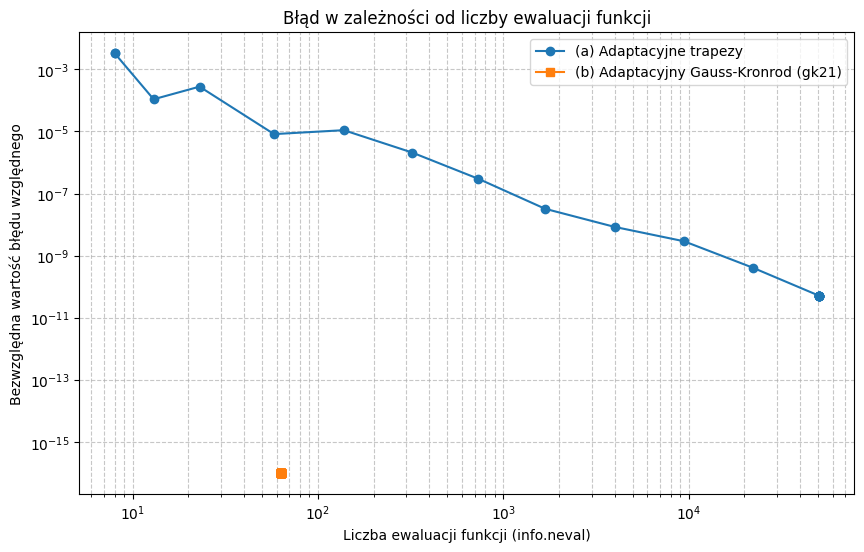

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(evals_trapz, errs_trapz_safe, 'o-', label='(a) Adaptacyjne trapezy')
plt.plot(evals_gk, errs_gk_safe, 's-', label='(b) Adaptacyjny Gauss-Kronrod (gk21)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Liczba ewaluacji funkcji (info.neval)')
plt.ylabel('Bezwzględna wartość błędu względnego')
plt.title('Błąd w zależności od liczby ewaluacji funkcji')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.show()